In [79]:
#importing All Necessary Liabraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix,roc_curve, auc)

print("All Liabraries Imported")

All Liabraries Imported


In [80]:
#Loading The Dataset
data = pd.read_csv("Air_Quality_noisy.csv")
df = pd.DataFrame(data)
print("Loaded Dataset is :")
df

Loaded Dataset is :


,CO,NO2,Temperature,Humidity,Air_Quality
0,0.597647,50.456078,10.348591,79.748516,50.0
1,8.827584,97.449766,19.293746,55.584297,144.0
2,3.650538,68.771496,34.213651,85.476758,80.0
3,NaN,194.338929,NaN,54.278303,141.0
4,NaN,166.251031,44.021473,36.103806,99.0
...,...,...,...,...,...
4843,7.982584,178.272935,41.789049,79.525395,187.0
4844,2.682068,24.727115,19.298746,61.534056,61.0
4845,0.607537,30.411479,33.528195,45.641220,39.0
4846,9.121086,160.369938,18.140812,NaN,NaN


In [81]:
#Getting Structural Info
print("Structural Information of the dataset before any preprocessing :")
df.info()
#Null Values in Each Column 
print(" ")
print(" ")
print("Null Values In Columns are :")
df.isnull().sum()

Structural Information of the dataset before any preprocessing :
<class 'pandas.DataFrame'>
RangeIndex: 4848 entries, 0 to 4847
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CO           4569 non-null   float64
 1   NO2          4610 non-null   float64
 2   Temperature  4611 non-null   float64
 3   Humidity     4612 non-null   float64
 4   Air_Quality  4703 non-null   float64
dtypes: float64(5)
memory usage: 189.5 KB
 
 
Null Values In Columns are :


CO             279
NO2            238
Temperature    237
Humidity       236
Air_Quality    145
dtype: int64

In [82]:
#Getting Statistical info of the dataset 
print("Sattistical info of the dataset before preprocessing is :")
df.describe()

Sattistical info of the dataset before preprocessing is :


,CO,NO2,Temperature,Humidity,Air_Quality
count,4569.000000,4610.000000,4611.000000,4612.000000,4703.000000
mean,3.603433,74.184977,27.007478,53.282834,85.594302
std,4.639945,81.283809,16.726650,32.977170,44.947907
min,-26.869959,-453.148395,-85.745317,-170.110885,4.000000
25%,1.148995,28.861147,18.086265,36.328035,46.000000
50%,2.877509,59.363488,26.845863,53.649679,80.000000
75%,6.003282,111.504287,36.183128,71.221798,117.000000
max,33.261316,592.777005,141.292875,278.027477,199.000000


In [83]:
#Handling the missing values In the dataset 
df.fillna(df.mean(), inplace=True)
print(" Missing values handled using MEAN\n")
print(df.isnull().sum())

 Missing values handled using MEAN

CO             0
NO2            0
Temperature    0
Humidity       0
Air_Quality    0
dtype: int64


In [84]:
#handling the duplicate values from the dataset
df.drop_duplicates()

,CO,NO2,Temperature,Humidity,Air_Quality
0,0.597647,50.456078,10.348591,79.748516,50.000000
1,8.827584,97.449766,19.293746,55.584297,144.000000
2,3.650538,68.771496,34.213651,85.476758,80.000000
3,3.603433,194.338929,27.007478,54.278303,141.000000
4,3.603433,166.251031,44.021473,36.103806,99.000000
...,...,...,...,...,...
4841,0.599014,147.307115,32.076425,62.721545,89.000000
4842,8.091083,113.260132,14.708392,89.994738,144.000000
4843,7.982584,178.272935,41.789049,79.525395,187.000000
4846,9.121086,160.369938,18.140812,53.282834,85.594302


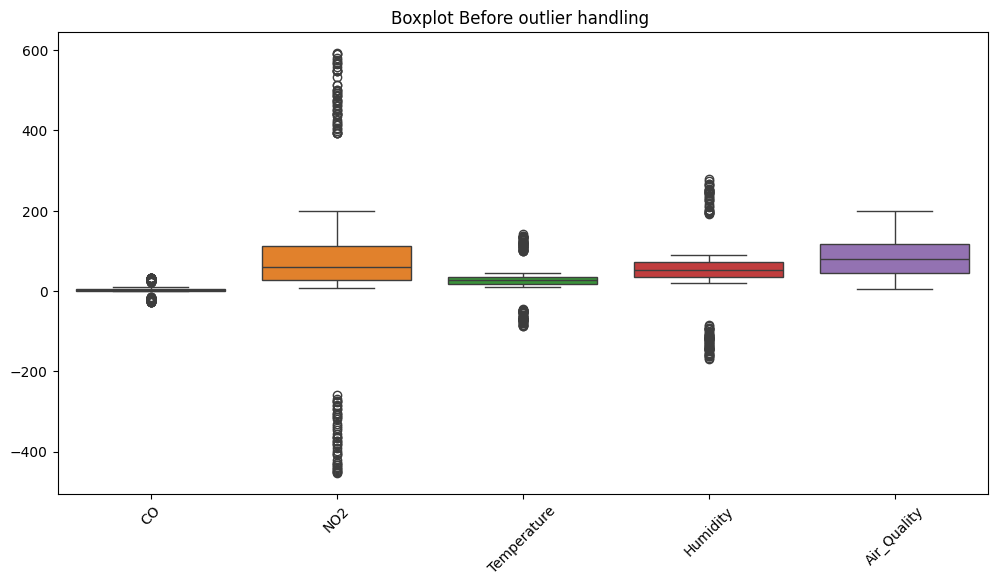

In [85]:
#Plotting Boxplot for detection of outlier in the given dataset
num_cols = data.select_dtypes(include=np.number).columns
plt.figure(figsize=(12,6))
sns.boxplot(data=data[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplot Before outlier handling ")
plt.show()

In [86]:
#Handling outliers in the given Dataset 
def remove_outliers_iqr(dataframe, columns):
    df_clean = dataframe.copy()
    outlier_report = {}
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
        outlier_report[col] = outliers
        # Clip instead of drop — preserves data size
        df_clean[col] = df_clean[col].clip(lower, upper)
    print('Outliers clipped per column:', outlier_report)
    return df_clean

df = remove_outliers_iqr(df, feature_cols)
print(f'Final dataset shape: {df.shape}')

Outliers clipped per column: {'CO': np.int64(99), 'NO2': np.int64(97), 'Temperature': np.int64(96), 'Humidity': np.int64(97)}
Final dataset shape: (4848, 5)


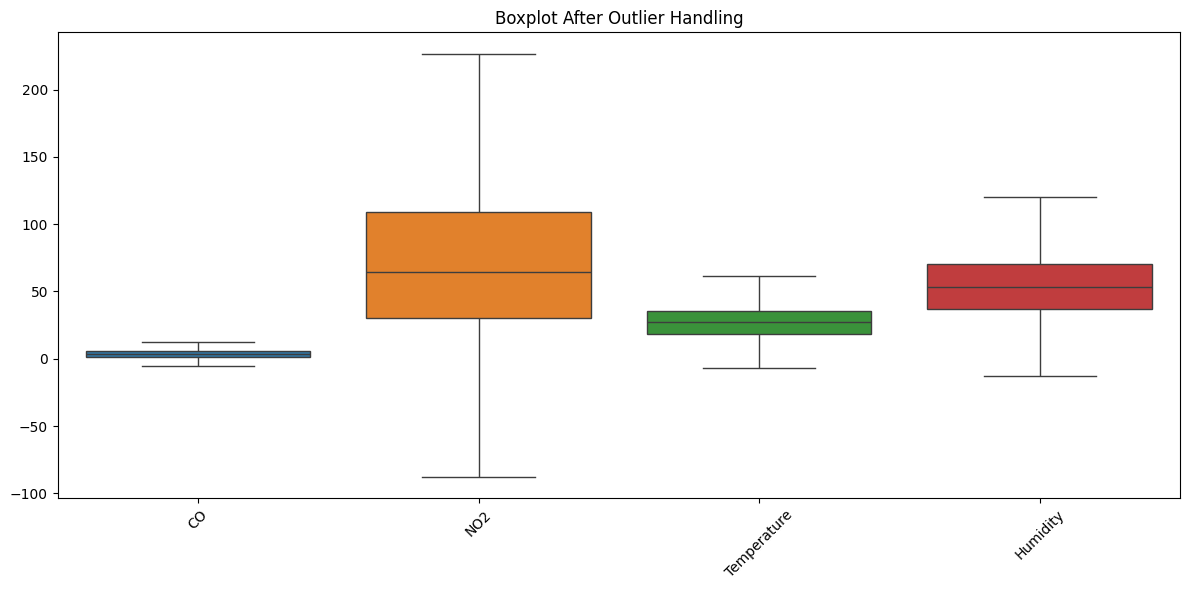

In [87]:
#Plotting Boxplot for detection of outlier in the given dataset after the outlier handling 
plt.figure(figsize=(12,6))
sns.boxplot(data=df[feature_cols])
plt.title('Boxplot After Outlier Handling')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [88]:
# function for labeling
def label_air_quality(aqi):
    if aqi <= 50:
        return "GOOD"
    elif aqi <= 100:
        return "Moderate"
    else:
        return "WORST"

In [89]:
# NEW COLUMN ADD
df["Air_Quality_Category"] = df["Air_Quality"].apply(label_air_quality)
print("Dataset after adding the Air_Quality_Category column :")
df

Dataset after adding the Air_Quality_Category column :


,CO,NO2,Temperature,Humidity,Air_Quality,Air_Quality_Category
0,0.597647,50.456078,10.348591,79.748516,50.000000,GOOD
1,8.827584,97.449766,19.293746,55.584297,144.000000,WORST
2,3.650538,68.771496,34.213651,85.476758,80.000000,Moderate
3,3.603433,194.338929,27.007478,54.278303,141.000000,WORST
4,3.603433,166.251031,44.021473,36.103806,99.000000,Moderate
...,...,...,...,...,...,...
4843,7.982584,178.272935,41.789049,79.525395,187.000000,WORST
4844,2.682068,24.727115,19.298746,61.534056,61.000000,Moderate
4845,0.607537,30.411479,33.528195,45.641220,39.000000,GOOD
4846,9.121086,160.369938,18.140812,53.282834,85.594302,Moderate


In [90]:
#Seperating the input and target feature from the given dataset 
X = df.drop(["Air_Quality", "Air_Quality_Category"], axis=1)
y = df["Air_Quality_Category"]
print(X)
print(" ")
print(" ")
print(y)

            CO         NO2  Temperature   Humidity
0     0.597647   50.456078    10.348591  79.748516
1     8.827584   97.449766    19.293746  55.584297
2     3.650538   68.771496    34.213651  85.476758
3     3.603433  194.338929    27.007478  54.278303
4     3.603433  166.251031    44.021473  36.103806
...        ...         ...          ...        ...
4843  7.982584  178.272935    41.789049  79.525395
4844  2.682068   24.727115    19.298746  61.534056
4845  0.607537   30.411479    33.528195  45.641220
4846  9.121086  160.369938    18.140812  53.282834
4847  0.255546   64.522207    27.007478  48.714350

[4848 rows x 4 columns]
 
 
0           GOOD
1          WORST
2       Moderate
3          WORST
4       Moderate
          ...   
4843       WORST
4844    Moderate
4845        GOOD
4846    Moderate
4847        GOOD
Name: Air_Quality_Category, Length: 4848, dtype: str


In [91]:
# dividing the data into training and testing data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Dividation Complted in the ratio 80:20")

Dividation Complted in the ratio 80:20


In [92]:
#Applying Standard Scalar to the given Dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling Done...")

Scaling Done...


In [93]:
#Forward Feature Selection
knn = KNeighborsClassifier()
forward = SequentialFeatureSelector(knn,n_features_to_select=3,direction='forward')
forward.fit(X_train_scaled, y_train)
X_train_forward = forward.transform(X_train_scaled)
X_test_forward = forward.transform(X_test_scaled)
selected_features = X.columns[forward.get_support()]
print("Forward Selected Features:", selected_features)

Forward Selected Features: Index(['CO', 'NO2', 'Temperature'], dtype='str')


In [94]:
#Backward Feature Selection
backward = SequentialFeatureSelector(knn,n_features_to_select=3,direction='backward')
backward.fit(X_train_scaled, y_train)
X_train_backward = backward.transform(X_train_scaled)
X_test_backward = backward.transform(X_test_scaled)
selected_features_backward = X.columns[backward.get_support()]
print("Backward Selected Features:", list(selected_features_backward))

Backward Selected Features: ['CO', 'NO2', 'Temperature']


In [95]:
#KNN with Hyperparameter Tuning
param_knn = {
    'n_neighbors':[3, 5, 7, 9, 11],
    'weights':['uniform', 'distance'],
    'metric':['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=5)
grid_knn.fit(X_train_forward, y_train)   

print('Best KNN Parameters:', grid_knn.best_params_)

Best KNN Parameters: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}


In [96]:
# KNN Evaluation
y_pred_knn = grid_knn.predict(X_test_forward)  
knn_acc = accuracy_score(y_test, y_pred_knn)
print(" ")
print(f'KNN Accuracy: {knn_acc:.4f} ({knn_acc*100:.2f}%)')
print(" ")
print(classification_report(y_test, y_pred_knn))

 
KNN Accuracy: 0.8619 (86.19%)
 
              precision    recall  f1-score   support

        GOOD       0.88      0.93      0.90       332
    Moderate       0.81      0.78      0.79       319
       WORST       0.90      0.87      0.88       319

    accuracy                           0.86       970
   macro avg       0.86      0.86      0.86       970
weighted avg       0.86      0.86      0.86       970



In [97]:
#Logistic Regression with Hyperparameter Tuning
param_lr = {
    'C':[0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],    
}
grid_lr = GridSearchCV(LogisticRegression(max_iter=2000),param_lr, cv=5)
grid_lr.fit(X_train_forward, y_train)
print('Best LR Parameters:', grid_lr.best_params_)

Best LR Parameters: {'C': 0.1, 'solver': 'lbfgs'}


In [98]:
# Logistic Regression Evaluation
y_pred_lr = grid_lr.predict(X_test_forward)   
lr_acc = accuracy_score(y_test, y_pred_lr)
print(" ")
print(f'Logistic Regression Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)')
print(" ")
print(classification_report(y_test, y_pred_lr))

 
Logistic Regression Accuracy: 0.8165 (81.65%)
 
              precision    recall  f1-score   support

        GOOD       0.83      0.88      0.85       332
    Moderate       0.73      0.76      0.74       319
       WORST       0.91      0.81      0.86       319

    accuracy                           0.82       970
   macro avg       0.82      0.82      0.82       970
weighted avg       0.82      0.82      0.82       970



In [140]:
#Decision Tree with Hyperparameter Tuning
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),{'max_depth': [3,5,7,10,None], 'min_samples_split': [2,5,10], 'criterion': ['gini','entropy']},cv=5)
grid_dt.fit(X_train_scaled, y_train)
print(f"  Best: {grid_dt.best_params_}")

  Best: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}


In [141]:
#Decision Tree Accuracy
y_pred = grid_dt.predict(X_test_scaled)
dt_acc = accuracy_score(y_test, y_pred)
print(f"Decison Tree Accuracy: {dt_acc*100:.2f}%")

Test Accuracy: 84.85%


In [142]:
#Random Forest with Hyperparameter Tuning
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),{'n_estimators': [100,200], 'max_depth': [None,10,20], 'max_features': ['sqrt','log2']},cv=5)
grid_rf.fit(X_train_scaled, y_train)
print(f"  Best: {grid_rf.best_params_}")

  Best: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200}


In [143]:
#Random Forest Accuracy
y_pred = grid_rf.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

Random Forest Test Accuracy: 87.84%


In [144]:
#Support vector Machine (SVM) with Hyperparameter Tuning
grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    {'C': [0.1,1,10,100], 'kernel': ['rbf','poly'], 'gamma': ['scale','auto']},
    cv=5, scoring='accuracy', n_jobs=-1
)
grid_svm.fit(X_train_forward, y_train)
print(f"  Best: {grid_svm.best_params_}")

  Best: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [145]:
#SVM Accuracy
y_pred = grid_svm.predict(X_test_forward)
sv_acc = accuracy_score(y_test, y_pred)
print(f"SVM Accuracy: {sv_acc*100:.2f}%")

SVM Test Accuracy: 83.71%


In [146]:
#Model  Evalation Summary
model_map = {
    'KNN':                (grid_knn,  X_test_forward),
    'Logistic Regression':(grid_lr,   X_test_forward),
    'Decision Tree':      (grid_dt,   X_test_scaled),
    'Random Forest':      (grid_rf,   X_test_scaled),
    'SVM':                (grid_svm,  X_test_forward),
}
results = []
predictions = {}

for name, (model, X_te) in model_map.items():
    y_pred = model.predict(X_te)
    predictions[name] = y_pred

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    f1m  = f1_score(y_test, y_pred, average='macro', zero_division=0)
   

    results.append({
        'Model': name,
        'Accuracy (%)': round(acc*100, 2),
        'Precision':    round(prec, 4),
        'Recall':       round(rec, 4),
        'F1 Weighted':  round(f1, 4),
        'F1 Macro':     round(f1m, 4),
    })

results_df = pd.DataFrame(results).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
results_df.index += 1   # rank from 1
print("\n Model Evaluation Summary (sorted by Accuracy):")
print(results_df.to_string())



 Model Evaluation Summary (sorted by Accuracy):
                 Model  Accuracy (%)  Precision  Recall  F1 Weighted  F1 Macro
1        Random Forest         87.84     0.8774  0.8784       0.8776    0.8771
2                  KNN         86.19     0.8613  0.8619       0.8613    0.8607
3        Decision Tree         84.85     0.8475  0.8485       0.8474    0.8466
4                  SVM         83.71     0.8367  0.8371       0.8366    0.8361
5  Logistic Regression         81.65     0.8209  0.8165       0.8173    0.8169


In [147]:
#Evaluation reports For All Models 
for name, y_pred in predictions.items():
    print(" ")
    print(f"  {name}")
    print(" ")
    print(classification_report(y_test, y_pred, target_names=['GOOD','Moderate','WORST']))


 
  KNN
 
              precision    recall  f1-score   support

        GOOD       0.88      0.93      0.90       332
    Moderate       0.81      0.78      0.79       319
       WORST       0.90      0.87      0.88       319

    accuracy                           0.86       970
   macro avg       0.86      0.86      0.86       970
weighted avg       0.86      0.86      0.86       970

 
  Logistic Regression
 
              precision    recall  f1-score   support

        GOOD       0.83      0.88      0.85       332
    Moderate       0.73      0.76      0.74       319
       WORST       0.91      0.81      0.86       319

    accuracy                           0.82       970
   macro avg       0.82      0.82      0.82       970
weighted avg       0.82      0.82      0.82       970

 
  Decision Tree
 
              precision    recall  f1-score   support

        GOOD       0.88      0.94      0.91       332
    Moderate       0.79      0.76      0.78       319
       WORST       

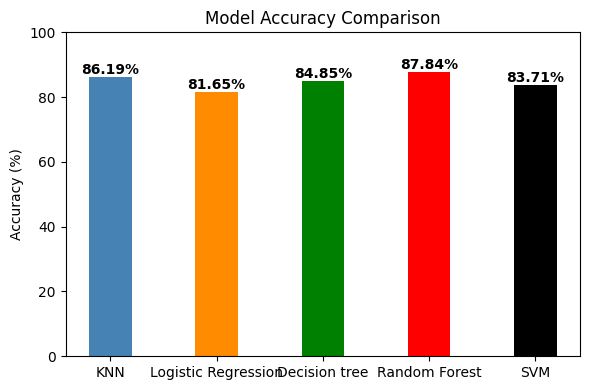


Best Model: Random Forest with 87.84% accuracy


In [148]:
#Comparasion betweeen All the applied Models 
models = ['KNN', 'Logistic Regression','Decision tree','Random Forest','SVM']
accuracies = [knn_acc, lr_acc, dt_acc, rf_acc, sv_acc]
plt.figure(figsize=(6, 4))
bars = plt.bar(models, [a*100 for a in accuracies], color=['steelblue', 'darkorange','green','red','black'], width=0.4)
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{acc*100:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'\nBest Model: {models[np.argmax(accuracies)]} with {max(accuracies)*100:.2f}% accuracy')